In [1]:
# Importing the libraries
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
plt.style.use("ggplot")

In [3]:
# Reading data
# PATH = "/lustre/groups/ml01/projects/inverse_perturbation_models/datasets/pbmc/adata_for_cellflow_datasets_with_embeddings.h5ad"
PATH = "/lustre/groups/ml01/projects/inverse_perturbation_models/datasets/pbmc/adata_for_cellflow_datasets_with_embeddings_and_200PCs.h5ad"
adata = sc.read_h5ad(PATH)

In [4]:
adata

AnnData object with n_obs × n_vars = 9697974 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [5]:
adata.obs.head(10)

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,log1p_n_genes_by_counts,log1p_total_counts,total_counts_MT,pct_counts_MT,log1p_total_counts_MT,donor,cytokine,treatment,cell_type,cytokine_family
89_103_005__s1,Donor10_4-1BBL,hg38,2236,4700,8656,89,103,5,H5,p2.A7,...,7.712891,8.455530,56.0,1.191490,4.043051,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_103_083__s1,Donor10_4-1BBL,hg38,2222,4337,8235,89,103,83,H5,p2.A7,...,7.706613,8.375169,71.0,1.637076,4.276666,Donor10,4-1BBL,cytokine,B Naive,TNF
89_103_085__s1,Donor10_4-1BBL,hg38,1690,3079,5870,89,103,85,H5,p2.A7,...,7.433075,8.032685,197.0,6.398181,5.288267,Donor10,4-1BBL,cytokine,B Intermediate/Memory,TNF
89_104_009__s1,Donor10_4-1BBL,hg38,1746,3015,5663,89,104,9,H5,p2.A8,...,7.465655,8.011686,84.0,2.786070,4.442651,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_025__s1,Donor10_4-1BBL,hg38,3182,6986,13153,89,104,25,H5,p2.A8,...,8.065579,8.851807,165.0,2.361867,5.111988,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_063__s1,Donor10_4-1BBL,hg38,1677,2809,5466,89,104,63,H5,p2.A8,...,7.425358,7.940940,54.0,1.922392,4.007333,Donor10,4-1BBL,cytokine,CD4 Naive,TNF
89_115_172__s1,Donor10_4-1BBL,hg38,1407,2178,4103,89,115,172,H5,p2.B7,...,7.249926,7.686621,34.0,1.561065,3.555348,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_115_183__s1,Donor10_4-1BBL,hg38,1259,1928,3624,89,115,183,H5,p2.B7,...,7.138867,7.564757,18.0,0.933610,2.944439,Donor10,4-1BBL,cytokine,NK,TNF
89_116_047__s1,Donor10_4-1BBL,hg38,2619,6170,11773,89,116,47,H5,p2.B8,...,7.870930,8.727616,228.0,3.695300,5.433722,Donor10,4-1BBL,cytokine,CD4 Memory,TNF
89_116_148__s1,Donor10_4-1BBL,hg38,1649,3169,6010,89,116,148,H5,p2.B8,...,7.408531,8.061487,38.0,1.199116,3.663562,Donor10,4-1BBL,cytokine,NK,TNF


In [7]:
columns = [
    "sample",
    "species",
    "donor",
    "cytokine",
    "treatment",
    "cell_type",
    "cytokine_family"
]
adata.obs.loc[:, columns]

,sample,species,donor,cytokine,treatment,cell_type,cytokine_family
89_103_005__s1,Donor10_4-1BBL,hg38,Donor10,4-1BBL,cytokine,CD8 Naive,TNF
89_103_083__s1,Donor10_4-1BBL,hg38,Donor10,4-1BBL,cytokine,B Naive,TNF
89_103_085__s1,Donor10_4-1BBL,hg38,Donor10,4-1BBL,cytokine,B Intermediate/Memory,TNF
89_104_009__s1,Donor10_4-1BBL,hg38,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
89_104_025__s1,Donor10_4-1BBL,hg38,Donor10,4-1BBL,cytokine,CD14 Mono,TNF
...,...,...,...,...,...,...,...
61_186_093__s144,Donor9_VEGF,hg38,Donor9,VEGF,cytokine,CD4 Memory,Growth factor
61_186_108__s144,Donor9_VEGF,hg38,Donor9,VEGF,cytokine,CD14 Mono,Growth factor
61_186_135__s144,Donor9_VEGF,hg38,Donor9,VEGF,cytokine,CD8 Naive,Growth factor
61_186_157__s144,Donor9_VEGF,hg38,Donor9,VEGF,cytokine,CD8 Naive,Growth factor


In [8]:
# 12 different donors
adata.obs["donor"].unique()

['Donor10', 'Donor11', 'Donor12', 'Donor1', 'Donor2', ..., 'Donor5', 'Donor6', 'Donor7', 'Donor8', 'Donor9']
Length: 12
Categories (12, object): ['Donor1', 'Donor2', 'Donor3', 'Donor4', ..., 'Donor9', 'Donor10', 'Donor11', 'Donor12']

In [9]:
# 1 species (HUMAN)
adata.obs["species"].unique()

['hg38']
Categories (1, object): ['hg38']

In [10]:
# 2 different treatments (cytokine and pbs treatments)
adata.obs["treatment"].unique()

['cytokine', 'PBS']
Categories (2, object): ['PBS', 'cytokine']

In [11]:
# cytokine family
adata.obs["cytokine_family"].unique()

['TNF', 'Other', 'Complement', 'IL-6/IL-12', 'Growth factor', ..., 'Interleukin - non-classified', 'IL-17', 'IL-10 (IL-20 subfamily)', 'Chemokine', NaN]
Length: 15
Categories (14, object): ['Chemokine', 'Common β chain', 'Common γ chain/IL-13/TSLP', 'Complement', ..., 'Interferon', 'Interleukin - non-classified', 'Other', 'TNF']

In [12]:
# cytokine
adata.obs["cytokine"].unique()

['4-1BBL', 'ADSF', 'APRIL', 'BAFF', 'C3a', ..., 'TPO', 'TRAIL', 'TSLP', 'TWEAK', 'VEGF']
Length: 91
Categories (91, object): ['4-1BBL', 'ADSF', 'APRIL', 'BAFF', ..., 'TRAIL', 'TSLP', 'TWEAK', 'VEGF']

In [14]:
# pbs treatments
tmp = adata.obs
tmp[tmp.treatment=="PBS"]["cytokine"].unique()

['PBS']
Categories (91, object): ['4-1BBL', 'ADSF', 'APRIL', 'BAFF', ..., 'TRAIL', 'TSLP', 'TWEAK', 'VEGF']

In [15]:
# 18 cell types
adata.obs["cell_type"].unique()

['CD8 Naive', 'B Naive', 'B Intermediate/Memory', 'CD14 Mono', 'CD4 Naive', ..., 'ILC', 'HSPC', 'Plasmablast', 'NKT', 'pDC']
Length: 18
Categories (18, object): ['B Intermediate/Memory', 'B Naive', 'CD4 Memory', 'CD4 Naive', ..., 'Plasmablast', 'Treg', 'cDC', 'pDC']

In [16]:
# donor embeddings
donor_embedding_shape = list(adata.uns["donor_embeddings"].values())[0].shape
print(f"{donor_embedding_shape=}")
for key, emb in adata.uns["donor_embeddings"].items():
    if emb.shape != donor_embedding_shape:
        print(key, emb.shape)

donor_embedding_shape=(2000,)


In [17]:
# esm2 embeddings
esm2_embedding_shape = list(adata.uns["esm2_embeddings"].values())[0].shape
print(f"{esm2_embedding_shape=}")
for key, emb in adata.uns["esm2_embeddings"].items():
    if emb.shape != esm2_embedding_shape:
        print(key, emb.shape)

esm2_embedding_shape=(2560,)


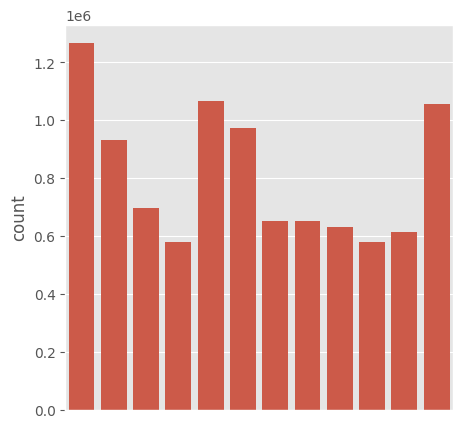

In [27]:
# histogram on patient level
fig, axes = plt.subplots(figsize=(5, 5))
axes.get_xaxis().set_visible(False)
# sns.histplot(data=adata.obs.head(1000_000), x="donor", ax=axes)
sns.barplot(adata.obs["donor"].value_counts())
plt.show()

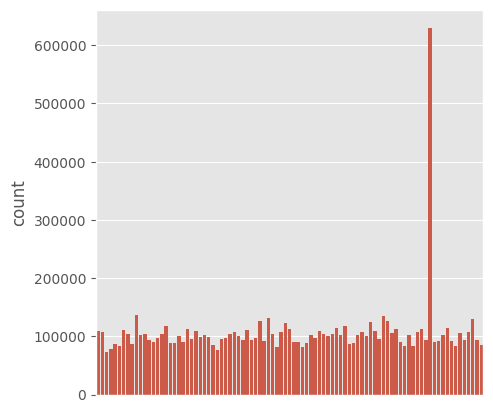

In [28]:
# histogram on cytokine level
fig, axes = plt.subplots(figsize=(5, 5))
axes.get_xaxis().set_visible(False)
# sns.histplot(data=adata.obs.head(1000_000), x="cytokine", ax=axes)
sns.barplot(adata.obs["cytokine"].value_counts())
plt.show()

In [29]:
# optionally subsample the data
SUBSAMPLE = True
SUBSAMPLE_SIZE = 1e-2

if SUBSAMPLE:
    # adata = sc.pp.subsample(adata, SUBSAMPLE_SIZE)
    sc.pp.subsample(adata, SUBSAMPLE_SIZE)
adata

AnnData object with n_obs × n_vars = 96979 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'

In [34]:
# normalize counts and log1p
# It is already log1p transformed
# sc.pp.normalize_total(adata)
# sc.pp.log1p(adata)

In [32]:
# pca
USE_RAPIDS = False

nPCs = 200

if USE_RAPIDS:
    import rapids_singlecell as rsc
    pca_fn = rsc.pp.pca
else:
    pca_fn = sc.pp.pca

pca_fn(
    adata,
    n_comps=nPCs,
)

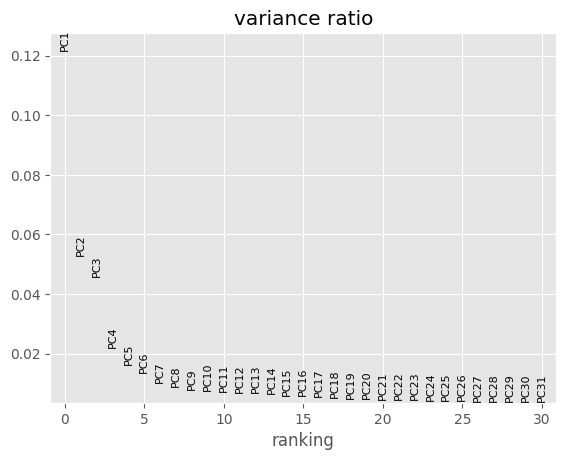

In [38]:
# plotting PCs variance ratios
sc.pl.pca_variance_ratio(adata)

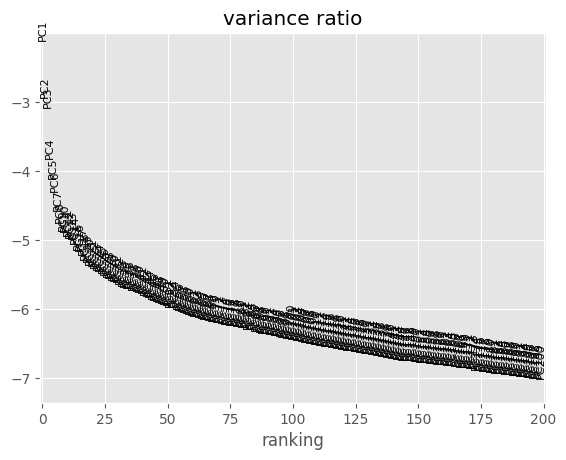

In [37]:
# plotting PCs variance ratios
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=200)

In [34]:
# writing the processed adata with pca and umap
WRITE_DATA = False
if WRITE_DATA:
    PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/sc_exp_design/data/pbmc/adata_for_cellflow_datasets_with_embeddings_and_200PCs.h5ad"
    adata.write_h5ad(PATH)

In [39]:
# computing neighbors and umap
sc.pp.neighbors(adata, transformer="sklearn")
sc.tl.umap(adata)

In [40]:
adata

AnnData object with n_obs × n_vars = 96979 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

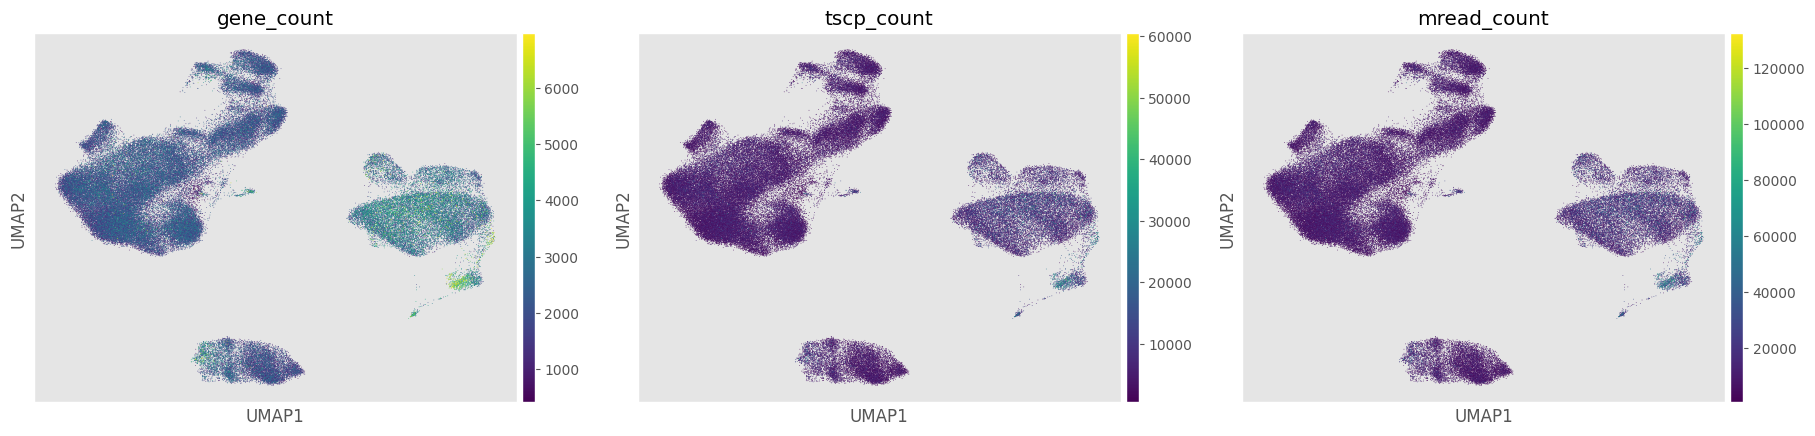

In [41]:
# visualizing umap
sc.pl.umap(adata, color=["gene_count", "tscp_count", "mread_count"])

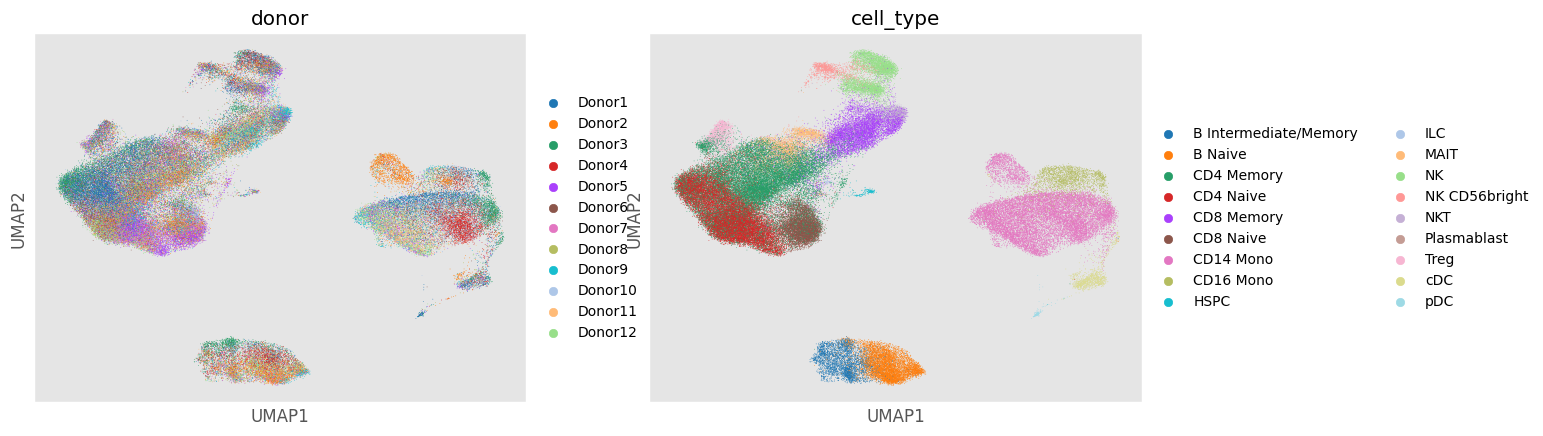

In [42]:
# visualizing umap
sc.pl.umap(adata, color=["donor", "cell_type"])

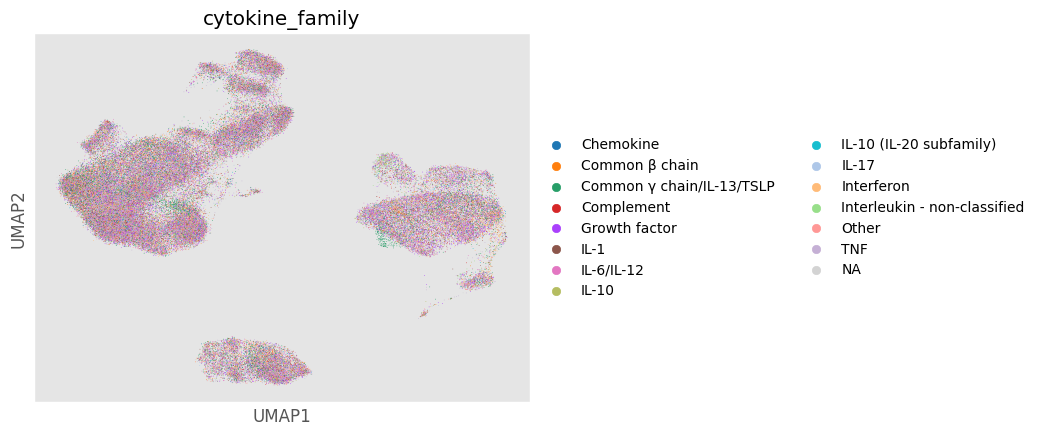

In [43]:
# visualizing umap
sc.pl.umap(adata, color=["cytokine_family"])

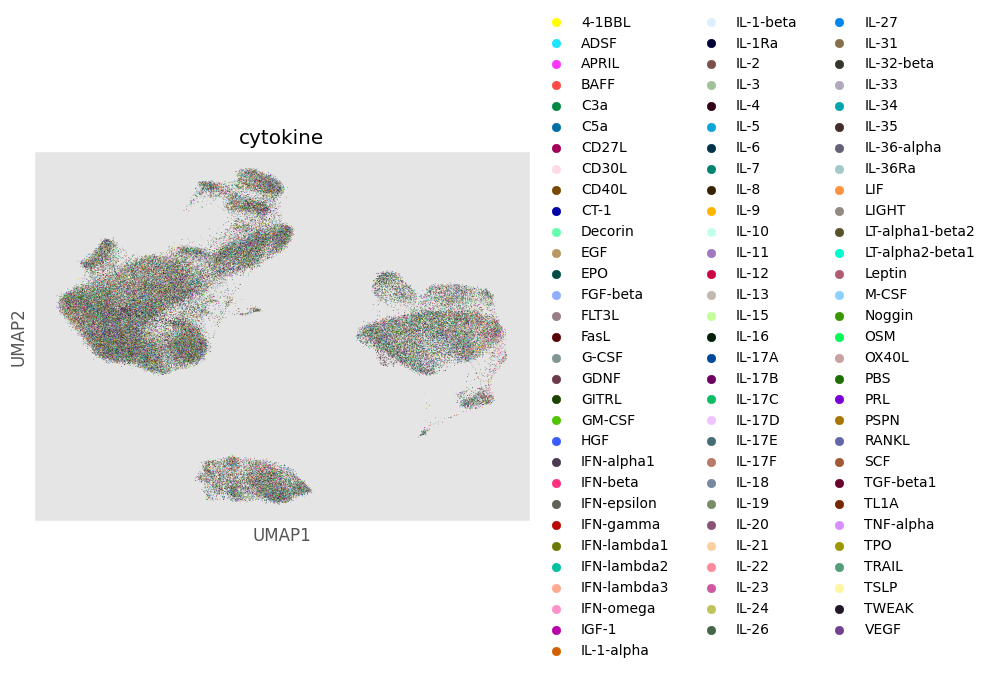

In [44]:
# visualizing umap
sc.pl.umap(adata, color=["cytokine"])

In [45]:
adata

AnnData object with n_obs × n_vars = 96979 × 2000
    obs: 'sample', 'species', 'gene_count', 'tscp_count', 'mread_count', 'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'total_counts_MT', 'pct_counts_MT', 'log1p_total_counts_MT', 'donor', 'cytokine', 'treatment', 'cell_type', 'cytokine_family'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'donor_embeddings', 'esm2_embeddings', 'hvg', 'log1p', 'pca', 'neighbors', 'umap', 'donor_colors', 'cell_type_colors', 'cytokine_family_colors', 'cytokine_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

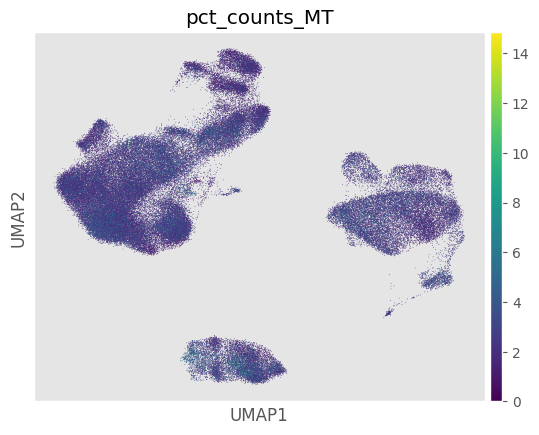

In [46]:
# visualizing umap
sc.pl.umap(adata, color=["pct_counts_MT"])

<Axes: xlabel='pct_counts_MT', ylabel='Count'>

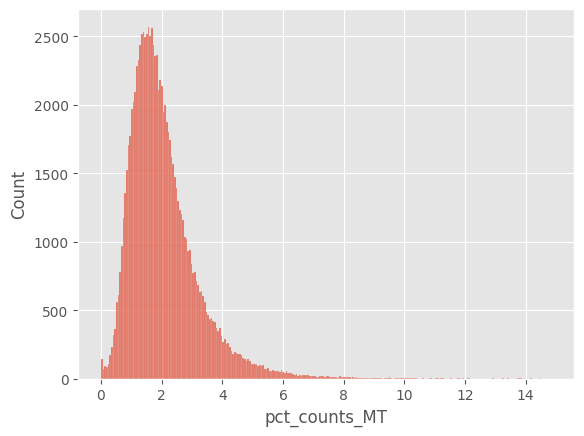

In [47]:
sns.histplot(adata.obs, x="pct_counts_MT")

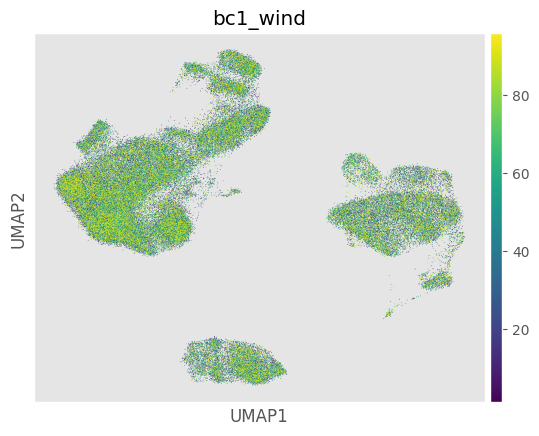

In [48]:
# visualizing umap
sc.pl.umap(adata, color=["bc1_wind"])

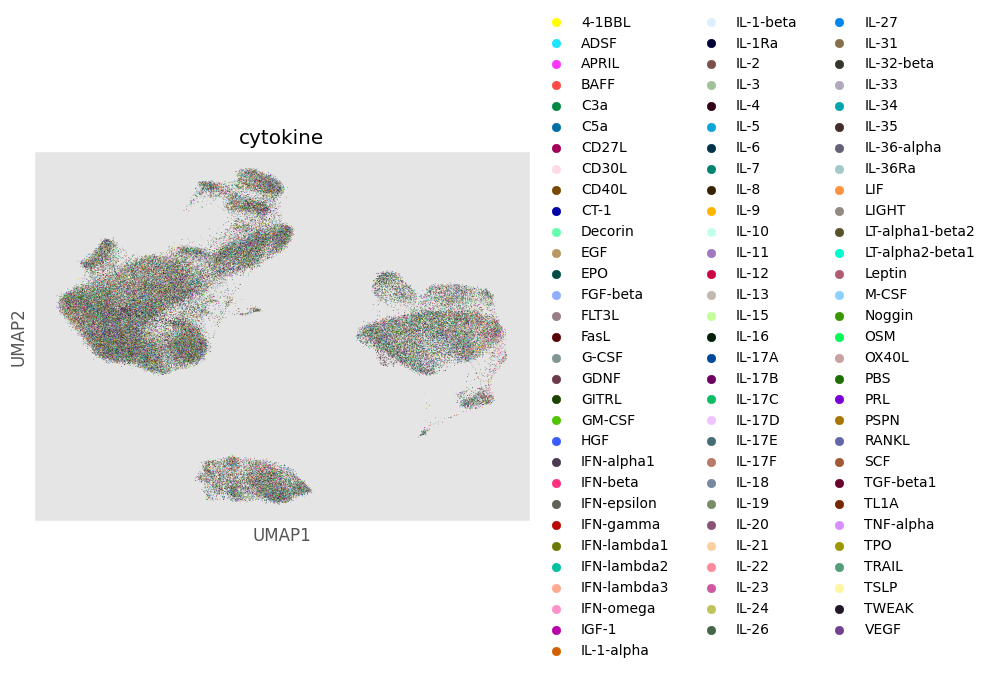

In [49]:
# visualizing umap
sc.pl.umap(adata, color=["cytokine"])

In [50]:
len(adata.uns["esm2_embeddings"])

93